# MountainCar DQN

## 实验目标

本实验使用 `DQN` 训练 `MountainCar-v0` 的离散动作策略。目标是让小车学会通过来回摆动积累动能，最终稳定爬上右侧山顶。这里的重点不仅是把训练跑起来，还要把 `DQN` 在延迟收益控制任务中的价值学习逻辑讲清楚。

## 为什么这里选择 DQN

`MountainCar-v0` 很适合用 `DQN`，原因很直接：

- 动作空间离散，天然适合 Q 值方法
- 状态空间连续，不能再用表格直接枚举
- 正确策略依赖长期回报，而不是短期即时收益
- 任务难点很典型，能清楚体现经验回放、目标网络和探索策略的作用

因此，这里使用 `DQN`，是为了把经典深度价值学习在延迟收益任务中的收敛过程讲清楚。

## 收敛判断方式

这个 notebook 不会笼统地说“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- episode return 是否持续改善
- 最近回合平均回报是否逐步优于 `-110`
- 最近成功率是否明显高于随机基线
- 固定评估阶段的平均回报和成功率是否达到稳定水平
- 策略可视化中是否出现连贯的推力切换区域

只有这些信号同时成立，才说明 `DQN` 不是偶然冲上去几次，而是真的学到了有效的蓄能与爬坡策略。

## 设备与并行说明

- 本实验固定使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不引入并行环境

这类经典 `DQN` 实验的关键不在多进程采样，而在经验回放、目标网络和训练预算是否足够稳定。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

In [2]:
ENV_ID = "MountainCar-v0"
TOTAL_TIMESTEPS = 220000
LEARNING_RATE = 1e-3
BUFFER_SIZE = 100000
LEARNING_STARTS = 2000
BATCH_SIZE = 128
GAMMA = 0.99
TRAIN_FREQ = 16
GRADIENT_STEPS = 8
TARGET_UPDATE_INTERVAL = 500
EXPLORATION_FRACTION = 0.45
EXPLORATION_INITIAL_EPS = 1.0
EXPLORATION_FINAL_EPS = 0.05
EVAL_EPISODES = 100
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 200
SUCCESS_THRESHOLD_RETURN = -110
SEED = 42
DEVICE = "cpu"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

## 参数选择说明

这里的参数选择明显向“更容易收敛”倾斜，而不是追求和前面实验完全对称：

- `TOTAL_TIMESTEPS = 220000`：给 MountainCar 更充分的训练预算
- `TRAIN_FREQ = 16` 与 `GRADIENT_STEPS = 8`：降低更新频率，但每次做更成块的优化
- `EXPLORATION_FRACTION = 0.45`：保留更长探索阶段，给小车更多机会学到完整摆动节奏
- `TARGET_UPDATE_INTERVAL = 500`：稳定目标网络更新
- `SUCCESS_THRESHOLD_RETURN = -110`：采用经典求解标准附近的判断线

如果训练后评估回报仍明显差于 `-110`，优先调整方向通常是：继续增加训练步数、放慢探索收缩、适度扩大网络宽度，或者继续提高回放利用率。

In [3]:
class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.episode_successes = []
        self.final_positions = []
        self.max_positions = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        new_obs = self.locals.get("new_obs")
        for idx, info in enumerate(infos):
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                episode_length = int(info["episode"]["l"])
                obs = new_obs[idx] if new_obs is not None else None
                final_position = float(obs[0]) if obs is not None else np.nan
                self.episode_returns.append(episode_return)
                self.episode_lengths.append(episode_length)
                self.episode_successes.append(int(episode_return >= SUCCESS_THRESHOLD_RETURN))
                self.final_positions.append(final_position)
                self.max_positions.append(final_position)
        return True

In [4]:
train_env = Monitor(gym.make(ENV_ID))
callback = EpisodeStatsCallback()

model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    train_freq=TRAIN_FREQ,
    gradient_steps=GRADIENT_STEPS,
    target_update_interval=TARGET_UPDATE_INTERVAL,
    exploration_fraction=EXPLORATION_FRACTION,
    exploration_initial_eps=EXPLORATION_INITIAL_EPS,
    exploration_final_eps=EXPLORATION_FINAL_EPS,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    device=DEVICE,
    seed=SEED,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
train_env.close()

Output()

In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
episode_success_series = pd.Series(callback.episode_successes, dtype=float)
rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series

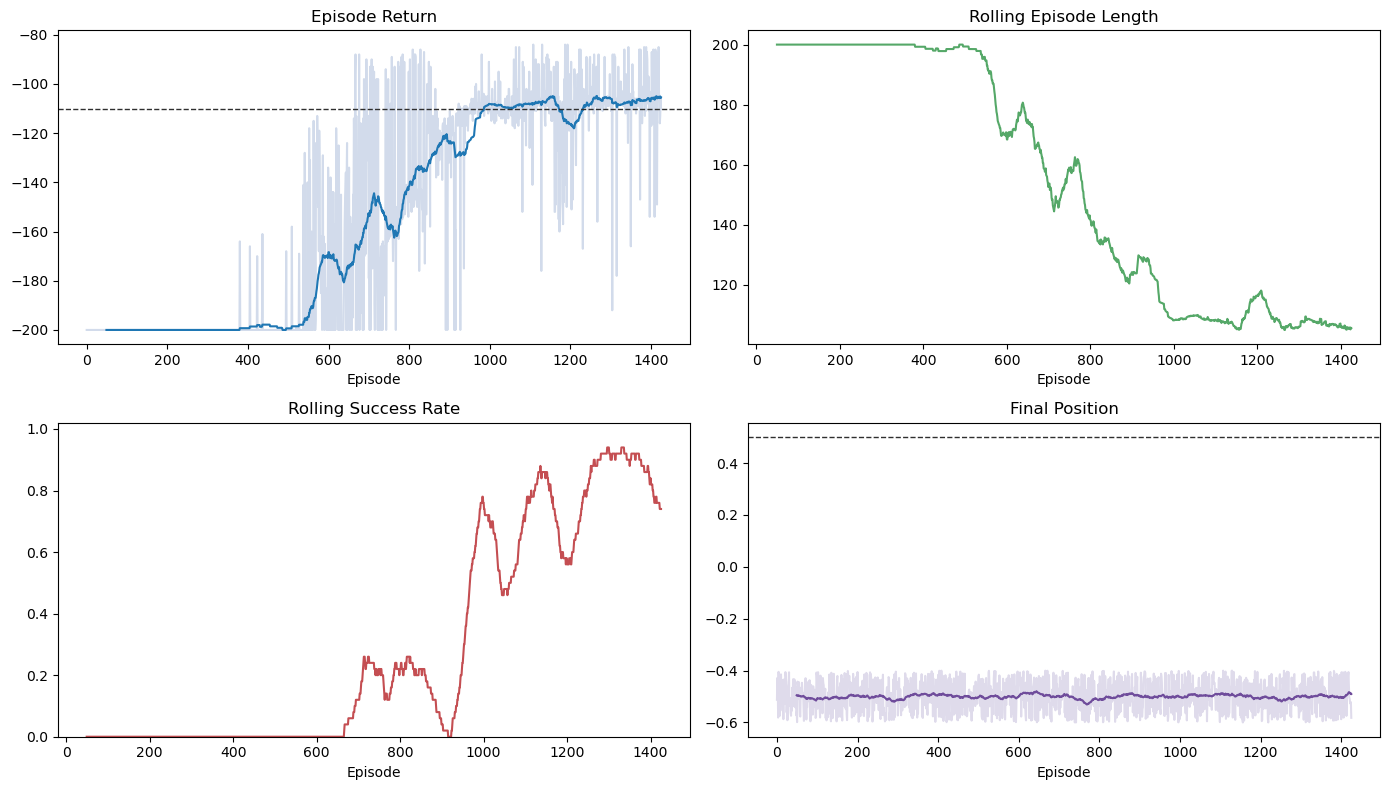

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(callback.episode_returns, alpha=0.25, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].axhline(SUCCESS_THRESHOLD_RETURN, linestyle="--", color="#2f2f2f", linewidth=1)
axes[0, 0].set_title("Episode Return")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_length, color="#55a868")
axes[0, 1].set_title("Rolling Episode Length")
axes[0, 1].set_xlabel("Episode")

axes[1, 0].plot(rolling_success, color="#c44e52")
axes[1, 0].set_title("Rolling Success Rate")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylim(0, 1.02)

axes[1, 1].plot(callback.final_positions, alpha=0.25, color="#8172b3")
axes[1, 1].plot(pd.Series(callback.final_positions).rolling(50).mean(), color="#6f4c9b")
axes[1, 1].axhline(0.5, linestyle="--", color="#2f2f2f", linewidth=1)
axes[1, 1].set_title("Final Position")
axes[1, 1].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
eval_returns = []
eval_lengths = []
eval_successes = []
eval_final_positions = []

for episode in range(EVAL_EPISODES):
    eval_env = gym.make(ENV_ID)
    obs, info = eval_env.reset(seed=SEED + 10000 + episode)
    total_reward = 0.0
    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_reward += reward
        if terminated or truncated:
            eval_returns.append(total_reward)
            eval_lengths.append(step + 1)
            eval_successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
            eval_final_positions.append(float(obs[0]))
            break
    eval_env.close()

eval_results = pd.DataFrame({
    "evaluation_return": eval_returns,
    "evaluation_length": eval_lengths,
    "evaluation_success": eval_successes,
    "final_position": eval_final_positions,
})
eval_results.head()

,evaluation_return,evaluation_length,evaluation_success,final_position
0,-102.0,102,1,0.526966
1,-89.0,89,1,0.504118
2,-102.0,102,1,0.510068
3,-101.0,101,1,0.503604
4,-103.0,103,1,0.525821


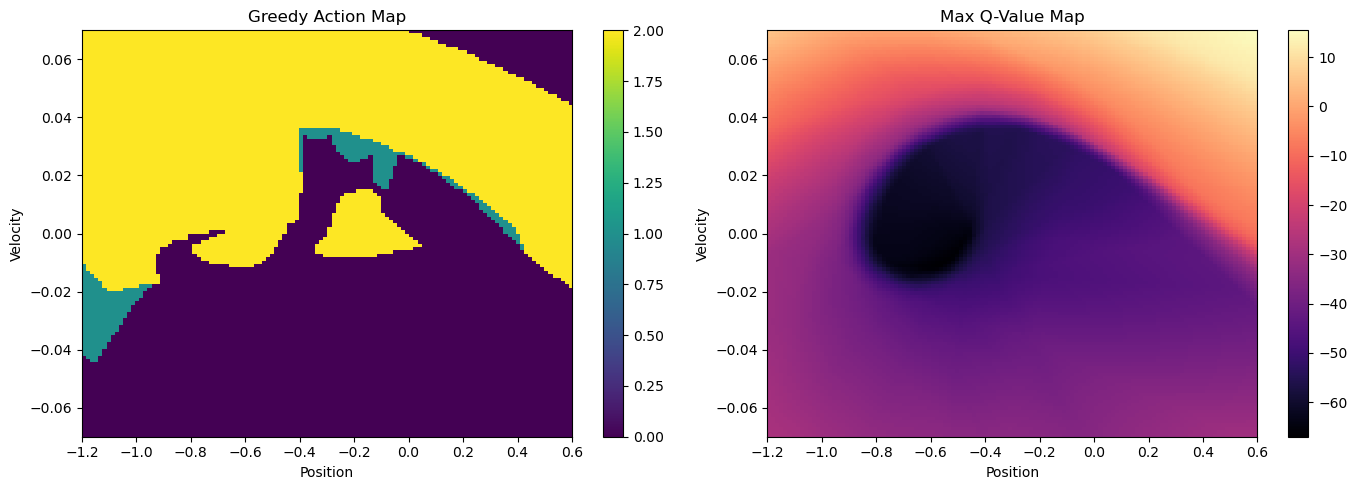

In [8]:
position_values = np.linspace(-1.2, 0.6, 120)
velocity_values = np.linspace(-0.07, 0.07, 120)
action_grid = np.zeros((len(velocity_values), len(position_values)))
value_grid = np.zeros_like(action_grid, dtype=float)

q_network = model.q_net
for i, velocity in enumerate(velocity_values):
    for j, position in enumerate(position_values):
        obs = np.array([position, velocity], dtype=np.float32)
        tensor = model.policy.obs_to_tensor(obs)[0]
        q_values = q_network(tensor).detach().cpu().numpy()[0]
        action_grid[i, j] = int(np.argmax(q_values))
        value_grid[i, j] = float(np.max(q_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

action_im = axes[0].imshow(action_grid, extent=[position_values[0], position_values[-1], velocity_values[0], velocity_values[-1]], origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title("Greedy Action Map")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Velocity")
fig.colorbar(action_im, ax=axes[0])

value_im = axes[1].imshow(value_grid, extent=[position_values[0], position_values[-1], velocity_values[0], velocity_values[-1]], origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("Max Q-Value Map")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
fig.colorbar(value_im, ax=axes[1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 20000 + rollout_idx)
    frames = []
    total_reward = 0.0
    best_position = float(obs[0])

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(int(action))
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.extend([final_frame] * 20)
            rollout_summaries.append({
                "rollout_index": rollout_idx + 1,
                "seed": SEED + 20000 + rollout_idx,
                "total_reward": float(total_reward),
                "steps": step + 1,
                "success": int(total_reward >= SUCCESS_THRESHOLD_RETURN),
                "final_position": float(obs[0]),
                "max_position": float(best_position),
            })
            break

    if frames:
        imageio.mimsave(RESULTS_DIR / f"dqn_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,steps,success,final_position,max_position
0,1,20042,-90.0,90,1,0.511142,0.511142
1,2,20043,-102.0,102,1,0.505977,0.505977
2,3,20044,-102.0,102,1,0.504730,0.504730


In [10]:
metrics = pd.DataFrame({
    "metric": [
        "device",
        "total_timesteps",
        "recent_episode_return_last_50",
        "recent_episode_length_last_50",
        "recent_success_rate_last_50",
        "evaluation_average_return",
        "evaluation_return_std",
        "evaluation_average_length",
        "evaluation_success_rate",
        "evaluation_average_final_position",
    ],
    "value": [
        DEVICE,
        TOTAL_TIMESTEPS,
        float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
        float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0,
        float(episode_success_series.tail(50).mean()) if len(episode_success_series) > 0 else 0.0,
        float(np.mean(eval_returns)),
        float(np.std(eval_returns)),
        float(np.mean(eval_lengths)),
        float(np.mean(eval_successes)),
        float(np.mean(eval_final_positions)),
    ],
})
metrics

,metric,value
0,device,cpu
1,total_timesteps,220000
2,recent_episode_return_last_50,-105.52
3,recent_episode_length_last_50,105.52
4,recent_success_rate_last_50,0.74
5,evaluation_average_return,-100.28
6,evaluation_return_std,6.110777
7,evaluation_average_length,100.28
8,evaluation_success_rate,1.0
9,evaluation_average_final_position,0.512667


In [11]:
episode_summary = pd.DataFrame({
    "episode_return": callback.episode_returns,
    "episode_length": callback.episode_lengths,
    "episode_success": callback.episode_successes,
    "final_position": callback.final_positions,
})

episode_summary.to_csv(RESULTS_DIR / "dqn_episode_summary.csv", index=False)
eval_results.to_csv(RESULTS_DIR / "dqn_eval_results.csv", index=False)
metrics.to_csv(RESULTS_DIR / "dqn_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "dqn_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                           metric     value
                           device       cpu
                  total_timesteps    220000
    recent_episode_return_last_50   -105.52
    recent_episode_length_last_50    105.52
      recent_success_rate_last_50      0.74
        evaluation_average_return   -100.28
            evaluation_return_std  6.110777
        evaluation_average_length    100.28
          evaluation_success_rate       1.0
evaluation_average_final_position  0.512667


## 结果解读

如果评估平均回报稳定优于 `-110`，成功率显著高于随机基线，并且回放中能看到先左摆蓄能、再右冲登顶的节奏，就说明 `DQN` 已经学会了 MountainCar 的关键控制逻辑。